# ⚽ Predicting Football Players' Future Goal Contributions (G+A)

This notebook aims to build a machine learning model to predict a football player's future **Goals + Assists (G+A)**.
We utilize historical performance data from the **2023-2024** and **2024-2025** seasons to engineer robust features and predict the target metric (G+A) for the **2025-2026** season.

### 🎯 Objectives
- **Data Engineering:** Clean and combine multiple seasons of player statistics.
- **Feature Creation:** Develop metrics reflecting consistency, volatility, and per-90-minute rates.
- **Model Training:** Compare the performance of **Random Forest**, **Gradient Boosting**, and **XGBoost** regressors.
- **Evaluation:** Identify the most accurate model through MAE, RMSE, and feature importance analysis.

## 📦 1. Import Essential Libraries
Importing data manipulation tools (Pandas, NumPy) and machine learning modules from Scikit-Learn and XGBoost. We also suppress warnings for cleaner output.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 📂 2. Data Ingestion
Loading the seasonal datasets. The features will be built from the `23-24` and `24-25` datasets, while the `25-26` dataset provides our target variable (future G+A).

In [2]:
df23 = pd.read_csv('ModelData/football-data_23-24.csv') 
df24 = pd.read_csv('ModelData/football-data_24-25.csv')
df25 = pd.read_csv('ModelData/football-data_25-26.csv')

print(f"2023-2024 shape: {df23.shape}")
print(f"2024-2025 shape: {df24.shape}")
print(f"2025-2026 shape: {df25.shape}")

2023-2024 shape: (2852, 37)
2024-2025 shape: (2854, 267)
2025-2026 shape: (2779, 102)


## 🛠️ 3. Data Preparation & Feature Engineering
We merge the datasets and filter out players with low playing time to ensure our models train on reliable data. 

**Key Engineered Features:**
- **Per 90 Metrics:** Normalizing stats (G+A, xG, xAG) by minutes played.
- **Consistency & Volatility:** Variance and standard deviation of G+A across past seasons.
- **Trend:** The momentum or drop in G+A from the 23-24 to 24-25 seasons.

In [3]:
base_features = ['Min', '90s', 'Gls', 'Ast', 'G+A', 'xG', 'npxG', 'xAG', 'PrgC', 'PrgP', 'PrgR']

df23_sub = df23[['Player', 'Age', 'Pos'] + base_features]
df23_sub = df23_sub.add_suffix('_23')
df23_sub = df23_sub.rename(columns={'Player_23': 'Player'})

df24_sub = df24[['Player'] + base_features]
df24_sub = df24_sub.add_suffix('_24')
df24_sub = df24_sub.rename(columns={'Player_24': 'Player'})

df25_target = df25[['Player', 'G+A', '90s']].copy()
df25_target = df25_target.rename(columns={'G+A': 'Target_G+A', '90s': '90s_25'})
df25_target['Target_GA_per90'] = df25_target['Target_G+A'] / df25_target['90s_25']

cleandf = df23_sub.merge(df24_sub, on='Player', how='inner').merge(df25_target, on='Player', how='inner')
cleandf = cleandf.drop_duplicates(subset=['Player'])

cleandf = cleandf[(cleandf['90s_24'] >= 10) & (cleandf['90s_23'] >= 5)].copy()
cleandf['Age_current'] = cleandf['Age_23'].astype(float) + 2

for season in ['23', '24']:
    cleandf[f'GA_per90_{season}']  = cleandf[f'G+A_{season}']  / cleandf[f'90s_{season}']
    cleandf[f'xG_per90_{season}']  = cleandf[f'xG_{season}']   / cleandf[f'90s_{season}']
    cleandf[f'xAG_per90_{season}'] = cleandf[f'xAG_{season}']  / cleandf[f'90s_{season}']

cleandf['GA_consistency'] = (cleandf['GA_per90_24'] + cleandf['GA_per90_23']) / 2
cleandf['GA_volatility'] = abs(cleandf['GA_per90_24'] - cleandf['GA_per90_23'])
cleandf['xG_consistency']  = (cleandf['xG_per90_24']  + cleandf['xG_per90_23'])  / 2
cleandf['xG_volatility']   = abs(cleandf['xG_per90_24']  - cleandf['xG_per90_23'])
cleandf['xAG_consistency'] = (cleandf['xAG_per90_24'] + cleandf['xAG_per90_23']) / 2
cleandf['xAG_volatility']  = abs(cleandf['xAG_per90_24'] - cleandf['xAG_per90_23'])

cleandf['GA_trend'] = cleandf['GA_per90_24'] - cleandf['GA_per90_23']
cleandf['xG_trend'] = cleandf['xG_per90_24'] - cleandf['xG_per90_23']
cleandf['xAG_trend'] = cleandf['xAG_per90_24'] - cleandf['xAG_per90_23']

le = LabelEncoder()
cleandf['Pos_encoded'] = le.fit_transform(cleandf['Pos_23'].fillna('Unknown'))

print(f"Players after filter: {cleandf.shape[0]}")


Players after filter: 921


## 🌲 4. Baseline Model: Random Forest Regressor
We start with a Random Forest Regressor, an ensemble learning method that fits multiple decision trees. This serves as our robust baseline model to predict next season's performance.

In [4]:
features = ['Age_current', 'Pos_encoded', '90s_23', '90s_24','GA_per90_23', 'xG_per90_23', 'xAG_per90_23',
'GA_per90_24', 'xG_per90_24', 'xAG_per90_24','GA_consistency', 'GA_volatility', 'GA_trend', 'xG_consistency', 'xG_volatility', 'xG_trend',
'xAG_consistency', 'xAG_volatility', 'xAG_trend','PrgC_24', 'PrgP_24', 'PrgR_24']

X = cleandf[features].fillna(0)
y = cleandf['Target_GA_per90'].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_per90 = rf_model.predict(X_test)

results = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
results['Predicted_GA_per90'] = y_pred_per90
results['Projected_G+A'] = results['Predicted_GA_per90'] * results['90s_25']

mae = mean_absolute_error(results['Target_G+A'], results['Projected_G+A'])

all_predictions_per90 = rf_model.predict(X)
global_results = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results['Predicted_GA_per90'] = all_predictions_per90
global_results['Projected_G+A'] = global_results['Predicted_GA_per90'] * global_results['90s_25']

global_top = global_results.sort_values(by='Projected_G+A', ascending=False)

print("🌍 GLOBAL TOP 10 PREDICTIONS (Entire Dataset):")
print(global_top[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))

🌍 GLOBAL TOP 10 PREDICTIONS (Entire Dataset):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      31.429559
  Kylian Mbappé     FW          28      27.521128
 Erling Haaland     FW          32      26.941093
   Ante Budimir     FW          17      26.747336
  Michael Olise  FW,MF          33      24.884801
Mason Greenwood  MF,FW          21      22.969192
   Lamine Yamal     FW          27      22.675225
Serhou Guirassy     FW          17      20.868465
    Deniz Undav  FW,MF          24      20.327843
      Luis Díaz     FW          28      20.150753


## 🚀 5. Better Model: Gradient Boosting Regressor
Gradient Boosting builds trees sequentially, correcting errors from previous trees. This can potentially lower our Mean Absolute Error (MAE) compared to Random Forest.

In [5]:
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb_per90 = gb_model.predict(X_test)

test_results_gb = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
test_results_gb['Predicted_GA_per90'] = y_pred_gb_per90
test_results_gb['Projected_G+A'] = test_results_gb['Predicted_GA_per90'] * test_results_gb['90s_25']

gb_mae = mean_absolute_error(test_results_gb['Target_G+A'], test_results_gb['Projected_G+A'])

all_predictions_gb_per90 = gb_model.predict(X)
global_results_gb = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results_gb['Predicted_GA_per90'] = all_predictions_gb_per90
global_results_gb['Projected_G+A'] = global_results_gb['Predicted_GA_per90'] * global_results_gb['90s_25']

global_top_gb = global_results_gb.sort_values(by='Projected_G+A', ascending=False)

print("🚀 GLOBAL TOP 10 PREDICTIONS (Gradient Boosting):")
print(global_top_gb[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))


🚀 GLOBAL TOP 10 PREDICTIONS (Gradient Boosting):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      35.303134
 Erling Haaland     FW          32      29.725923
  Michael Olise  FW,MF          33      29.612402
  Kylian Mbappé     FW          28      27.692110
   Lamine Yamal     FW          27      26.252049
   Ante Budimir     FW          17      23.739803
Bruno Fernandes  MF,FW          27      22.336596
      Luis Díaz     FW          28      21.653571
    Deniz Undav  FW,MF          24      21.427280
Serhou Guirassy     FW          17      19.079176


## ⚡ 6. Advanced Model: Extreme Gradient Boosting (XGBoost)
XGBoost is highly optimized for tabular data and often yields the best performance. Let's train an XGBoost regressor and compare its predictions.

In [6]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb_per90 = xgb_model.predict(X_test)

test_results_xgb = cleandf.loc[X_test.index, ['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()
test_results_xgb['Predicted_GA_per90'] = y_pred_xgb_per90
test_results_xgb['Projected_G+A'] = test_results_xgb['Predicted_GA_per90'] * test_results_xgb['90s_25']

xgb_mae = mean_absolute_error(test_results_xgb['Target_G+A'], test_results_xgb['Projected_G+A'])

all_predictions_xgb_per90 = xgb_model.predict(X)
global_results_xgb = cleandf[['Player', 'Pos_23', 'Target_G+A', '90s_25']].copy()

global_results_xgb['Predicted_GA_per90'] = all_predictions_xgb_per90
global_results_xgb['Projected_G+A'] = global_results_xgb['Predicted_GA_per90'] * global_results_xgb['90s_25']

global_top_xgb = global_results_xgb.sort_values(by='Projected_G+A', ascending=False)

print("⚡ GLOBAL TOP 10 PREDICTIONS (XGBoost):")
print(global_top_xgb[['Player', 'Pos_23', 'Target_G+A', 'Projected_G+A']].head(10).to_string(index=False))

⚡ GLOBAL TOP 10 PREDICTIONS (XGBoost):
         Player Pos_23  Target_G+A  Projected_G+A
     Harry Kane     FW          38      33.648192
 Erling Haaland     FW          32      30.927722
  Michael Olise  FW,MF          33      30.438170
  Kylian Mbappé     FW          28      27.996697
   Lamine Yamal     FW          27      25.776508
      Luis Díaz     FW          28      25.171577
Serhou Guirassy     FW          17      23.135876
    Deniz Undav  FW,MF          24      21.976690
Bruno Fernandes  MF,FW          27      21.811701
   Ante Budimir     FW          17      21.023847


## 📊 7. Visualizations & Comprehensive Model Evaluation
In this section, we analyze the performance of all three models using visual diagnostics and evaluation metrics. We will look at:
1. **Model Comparison:** Assessing Test MAE.
2. **Prediction Accuracy:** Predicted vs Actual G+A scatter plots.
3. **Error Distribution:** Residuals of the XGBoost model.
4. **Feature Importance:** Understanding what drives the XGBoost predictions.
5. **Cross-Validation:** Ensuring model stability.
6. **Top Projections:** Highlighting the players with the highest predicted G+A.

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'


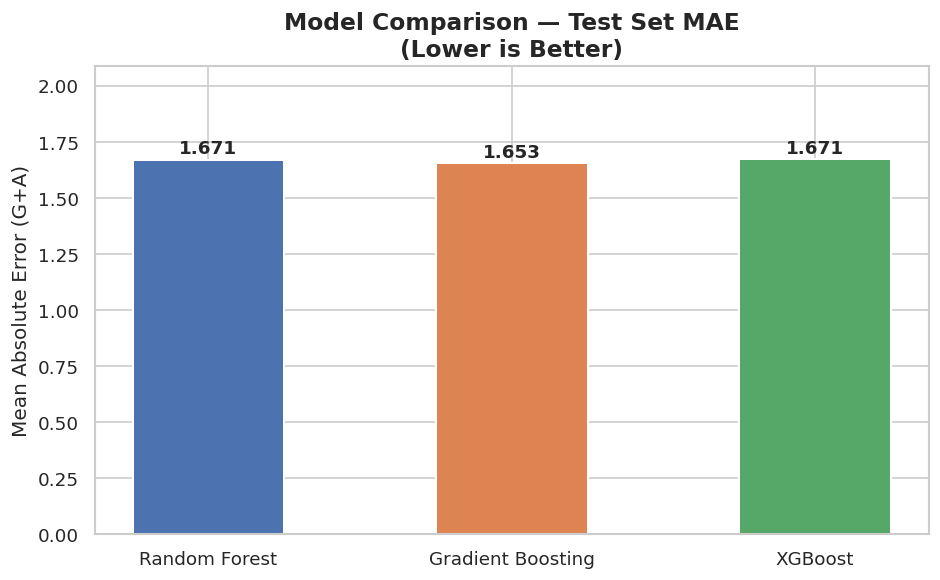

Best model: Gradient Boosting (MAE = 1.653)


In [8]:
models      = ['Random Forest', 'Gradient Boosting', 'XGBoost']
test_maes   = [mae, gb_mae, xgb_mae]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(models, test_maes, color=colors, width=0.5, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, test_maes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Mean Absolute Error (G+A)', fontsize=12)
ax.set_title('Model Comparison — Test Set MAE\n(Lower is Better)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(test_maes) * 1.25)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig('Visualizations/model_comparison_mae.png', bbox_inches='tight')
plt.show()
print(f'Best model: {models[test_maes.index(min(test_maes))]} (MAE = {min(test_maes):.3f})')


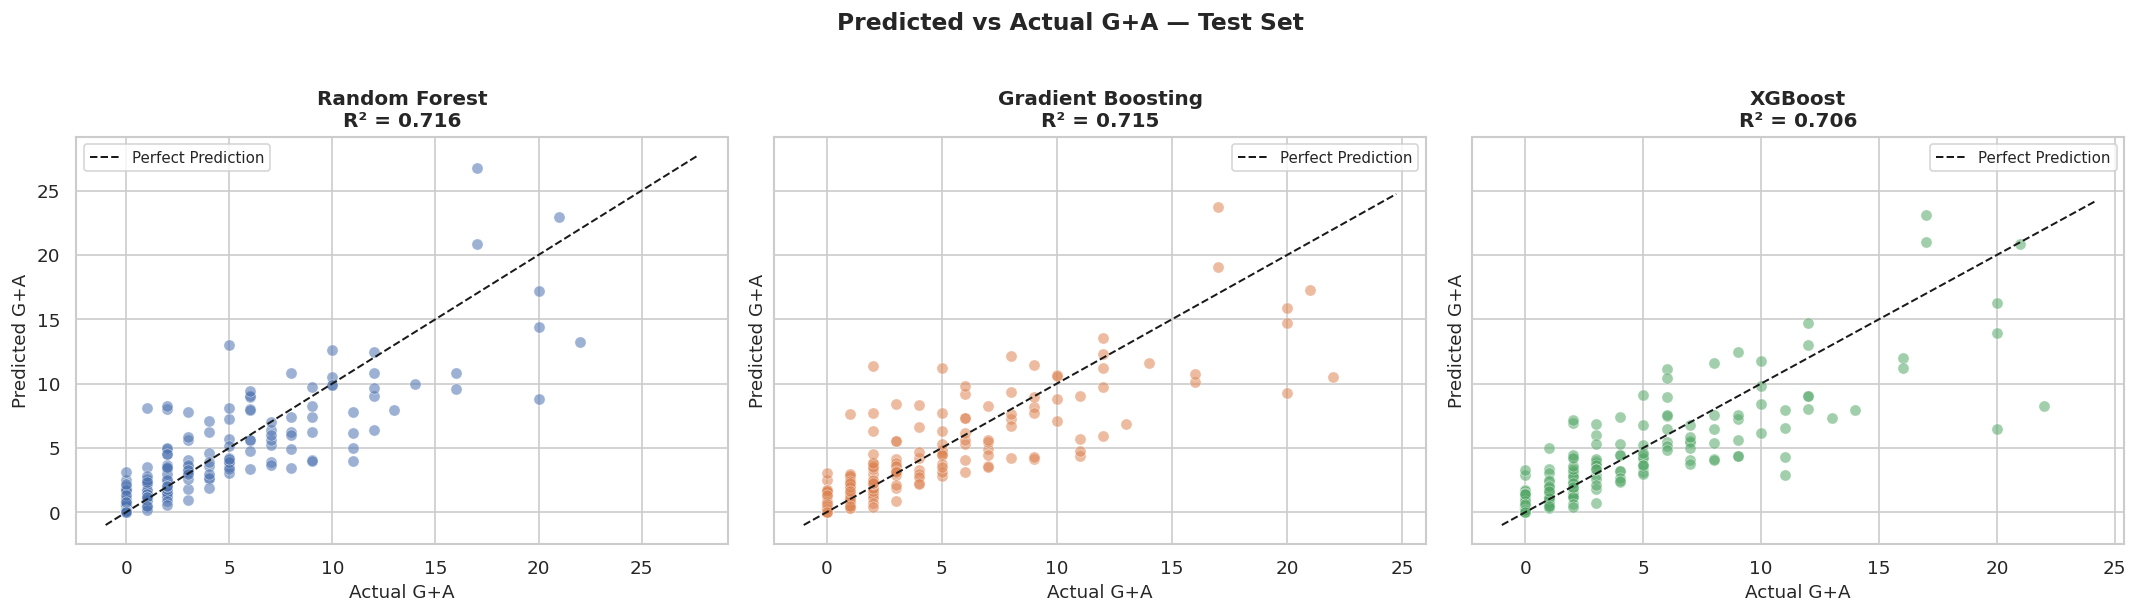

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

model_data = [
    ('Random Forest',      results,         '#4C72B0'),
    ('Gradient Boosting',  test_results_gb, '#DD8452'),
    ('XGBoost',            test_results_xgb,'#55A868'),
]

for ax, (name, df, color) in zip(axes, model_data):
    actual    = df['Target_G+A']
    predicted = df['Projected_G+A']
    r2 = r2_score(actual, predicted)
    
    ax.scatter(actual, predicted, alpha=0.55, color=color, edgecolors='white', linewidth=0.4, s=45)
    
    # Perfect-prediction line
    lims = [min(actual.min(), predicted.min()) - 1, max(actual.max(), predicted.max()) + 1]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual G+A', fontsize=11)
    ax.set_ylabel('Predicted G+A', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual G+A — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/predicted_vs_actual.png', bbox_inches='tight')
plt.show()


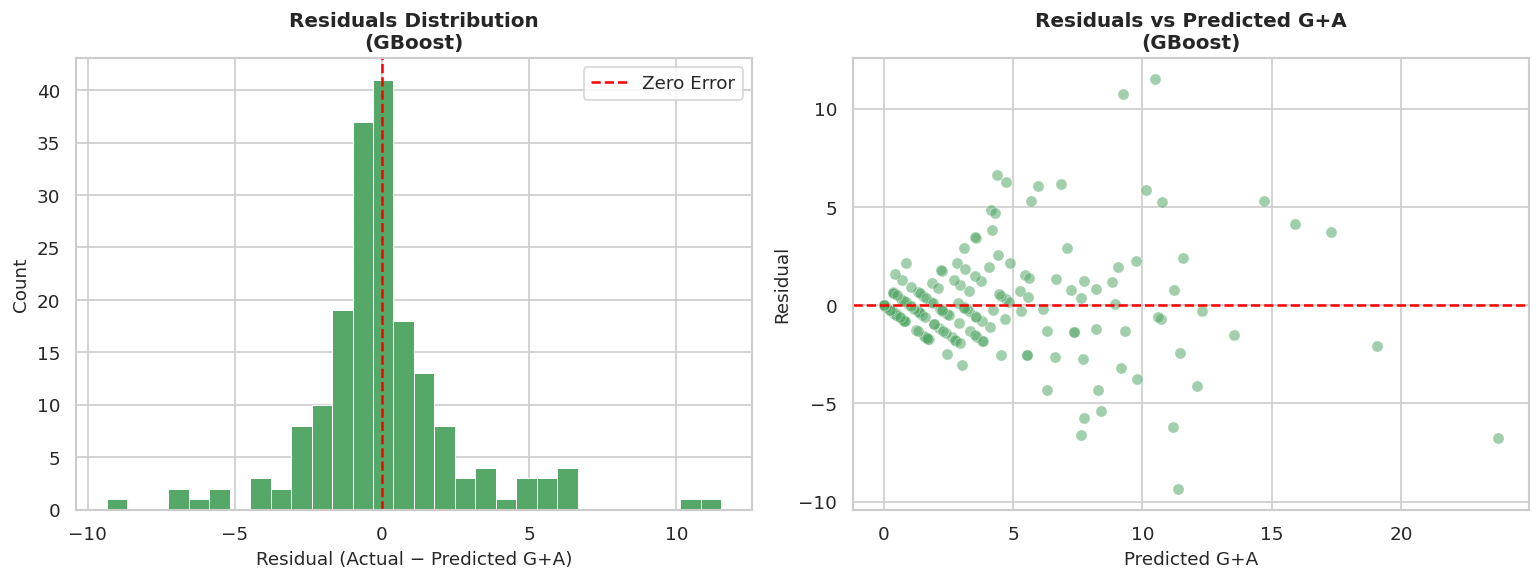

Mean Residual: 0.0225  |  Std: 2.5827


In [10]:
residuals_gb = test_results_gb['Target_G+A'] - test_results_gb['Projected_G+A']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(residuals_gb, bins=30, color='#55A868', edgecolor='white', linewidth=0.6)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[0].set_xlabel('Residual (Actual − Predicted G+A)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Residuals Distribution\n(GBoost)', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(test_results_gb['Projected_G+A'], residuals_gb,
                alpha=0.55, color='#55A868', edgecolors='white', linewidth=0.4, s=45)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted G+A', fontsize=11)
axes[1].set_ylabel('Residual', fontsize=11)
axes[1].set_title('Residuals vs Predicted G+A\n(GBoost)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Visualizations/residuals_gb.png', bbox_inches='tight')
plt.show()
print(f'Mean Residual: {residuals_gb.mean():.4f}  |  Std: {residuals_gb.std():.4f}')


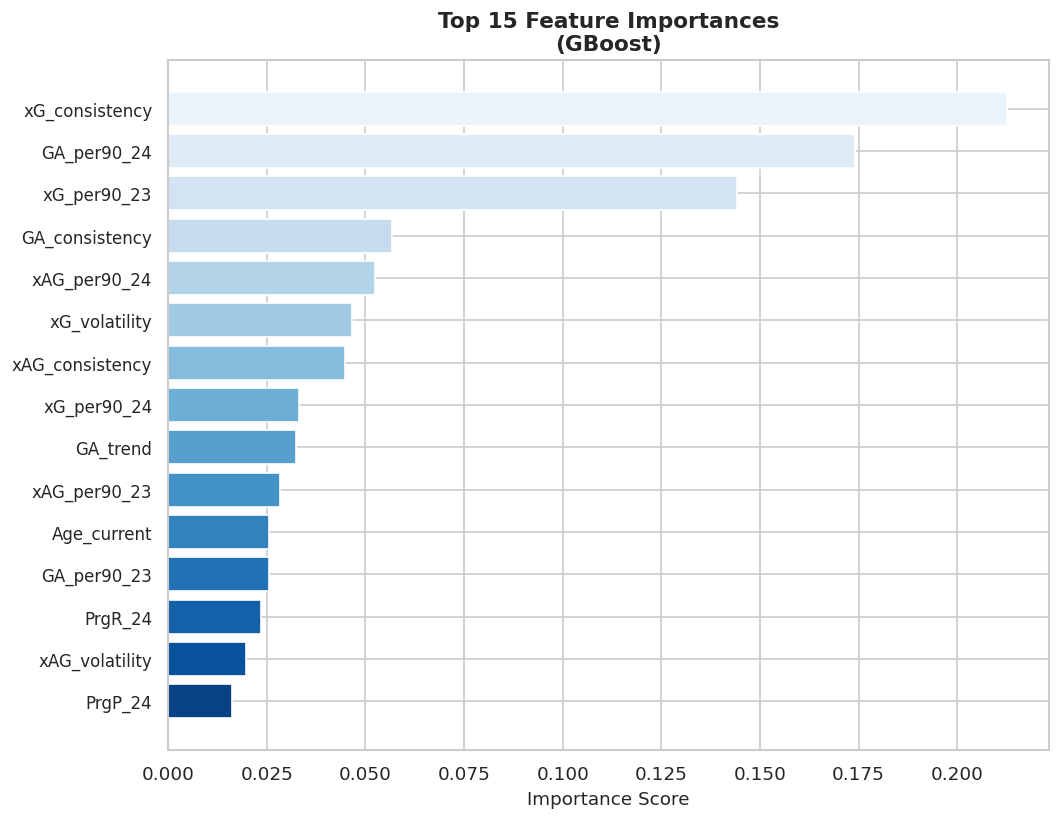

In [11]:
importances = gb_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('Blues_r', len(feat_df))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 15 Feature Importances\n(GBoost)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('Visualizations/feature_importance_gb.png', bbox_inches='tight')
plt.show()


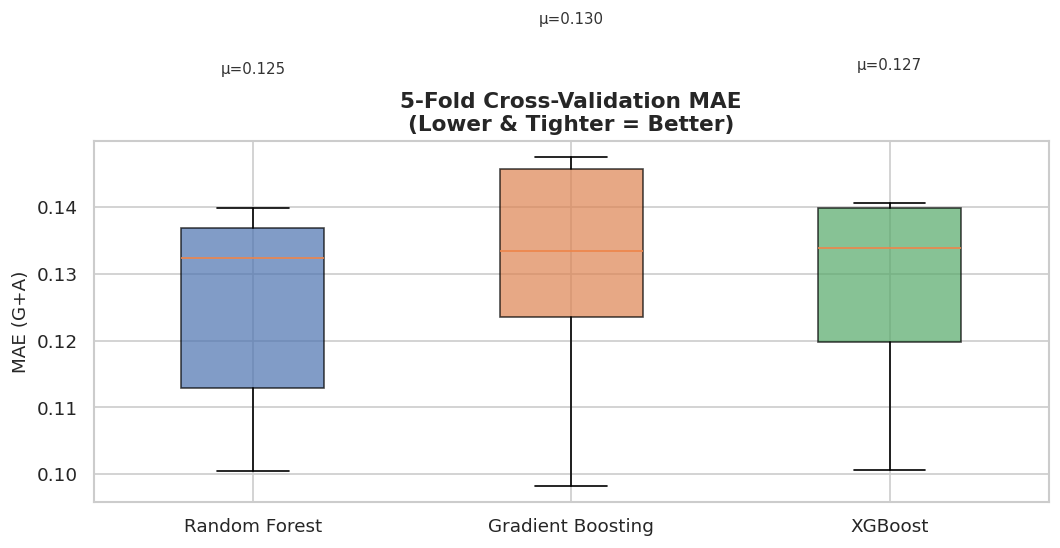

Cross-Validation Results:
  Random Forest        Mean MAE = 0.125  |  Std = 0.015
  Gradient Boosting    Mean MAE = 0.130  |  Std = 0.018
  XGBoost              Mean MAE = 0.127  |  Std = 0.015


In [12]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rf  = -cross_val_score(rf_model,  X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_gb  = -cross_val_score(gb_model,  X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_xgb = -cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

cv_data = {
    'Random Forest':      cv_rf,
    'Gradient Boosting':  cv_gb,
    'XGBoost':            cv_xgb,
}

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(list(cv_data.values()), labels=list(cv_data.keys()),
                patch_artist=True, notch=False, widths=0.45)

box_colors = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('MAE (G+A)', fontsize=11)
ax.set_title('5-Fold Cross-Validation MAE\n(Lower & Tighter = Better)', fontsize=13, fontweight='bold')

for i, (name, scores) in enumerate(cv_data.items(), 1):
    ax.text(i, scores.max() + 0.02, f'μ={scores.mean():.3f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('Visualizations/cross_validation.png', bbox_inches='tight')
plt.show()

print('Cross-Validation Results:')
for name, scores in cv_data.items():
    print(f'  {name:<20} Mean MAE = {scores.mean():.3f}  |  Std = {scores.std():.3f}')


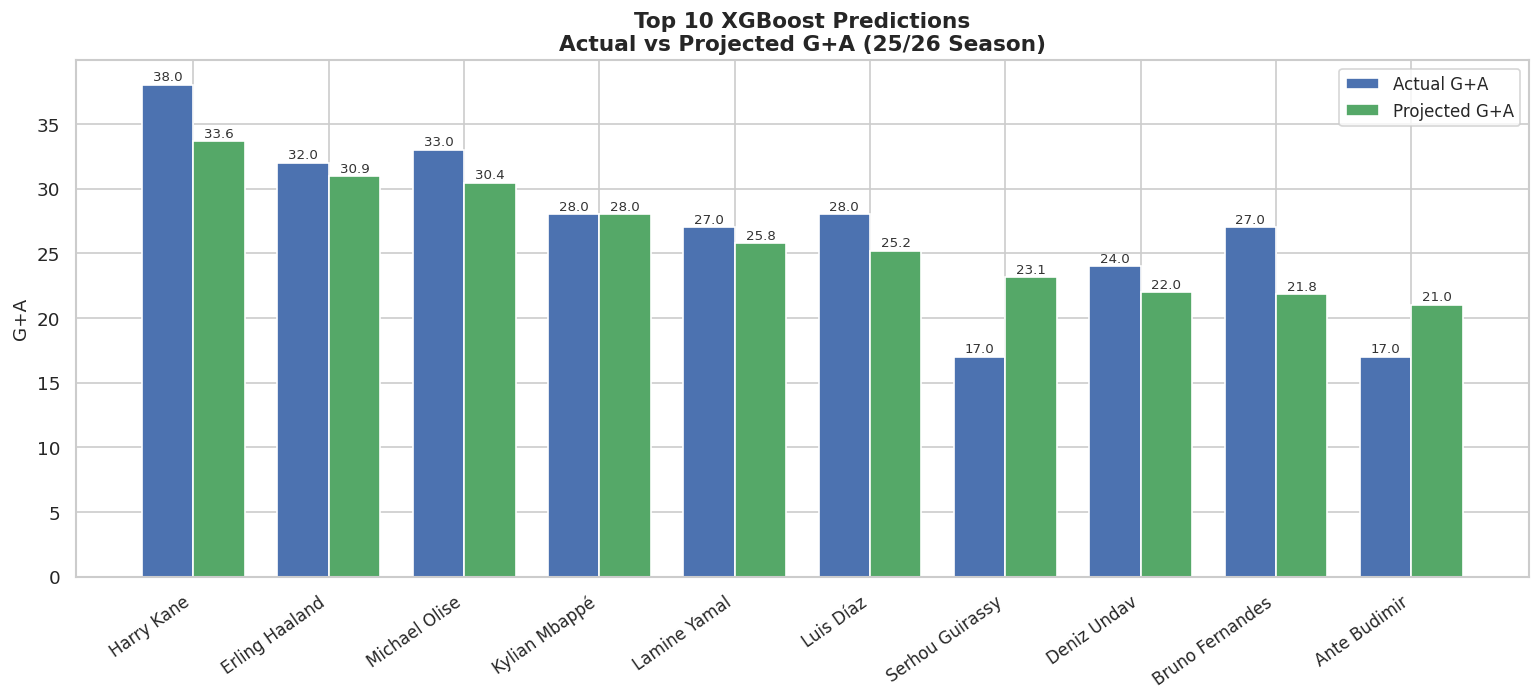

In [13]:
top10 = global_results_xgb.sort_values('Projected_G+A', ascending=False).head(10).copy()

x = range(len(top10))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar([i - width/2 for i in x], top10['Target_G+A'],  width, label='Actual G+A',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10['Projected_G+A'], width, label='Projected G+A', color='#55A868', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(top10['Player'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('G+A', fontsize=11)
ax.set_title('Top 10 XGBoost Predictions\nActual vs Projected G+A (25/26 Season)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#333')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.savefig('Visualizations/top10_predictions.png', bbox_inches='tight')
plt.show()


In [14]:
summary_rows = []

for name, df in [('Random Forest', results), ('Gradient Boosting', test_results_gb), ('XGBoost', test_results_xgb)]:
    actual    = df['Target_G+A']
    predicted = df['Projected_G+A']
    summary_rows.append({
        'Model':   name,
        'MAE':     round(mean_absolute_error(actual, predicted), 4),
        'RMSE':    round(mean_squared_error(actual, predicted) ** 0.5, 4),
        'R²':      round(r2_score(actual, predicted), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('='*55)
print('         MODEL EVALUATION SUMMARY (TEST SET)')
print('='*55)
print(summary_df.to_string())
print('='*55)

best_model = summary_df['MAE'].idxmin()
print(f'\n✅ Best Model by MAE: {best_model} ({summary_df.loc[best_model, "MAE"]} G+A off on average)')


         MODEL EVALUATION SUMMARY (TEST SET)
                      MAE    RMSE      R²
Model                                    
Random Forest      1.6705  2.5736  0.7155
Gradient Boosting  1.6531  2.5758  0.7150
XGBoost            1.6710  2.6143  0.7064

✅ Best Model by MAE: Gradient Boosting (1.6531 G+A off on average)
